In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

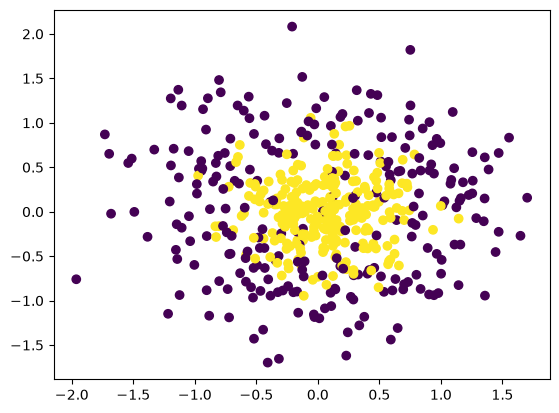

In [44]:
np.random.seed(42)
X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42) 
plt.scatter(X[:,0] , X[:,1] , c=y)

In [45]:
from sklearn.ensemble import AdaBoostClassifier 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
adaboost=AdaBoostClassifier(n_estimators=500)
adaboost.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",500
,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](500,)","[0.37,0.41,0.37,...,0.5 ,0.5 ,0.5 ]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](500,)","[0.53,0.38,0.52,...,0.02,0.02,0.02]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1861594770), DecisionTreeC...tate=13470137), DecisionTreeC...state=4466271), DecisionTreeC...te=1531112192), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](2,)","[0.51,0.49]"


In [46]:
y_pred = adaboost.predict(X_test)
from sklearn.metrics import accuracy_score 
accuracy_score(y_test , y_pred)

0.84

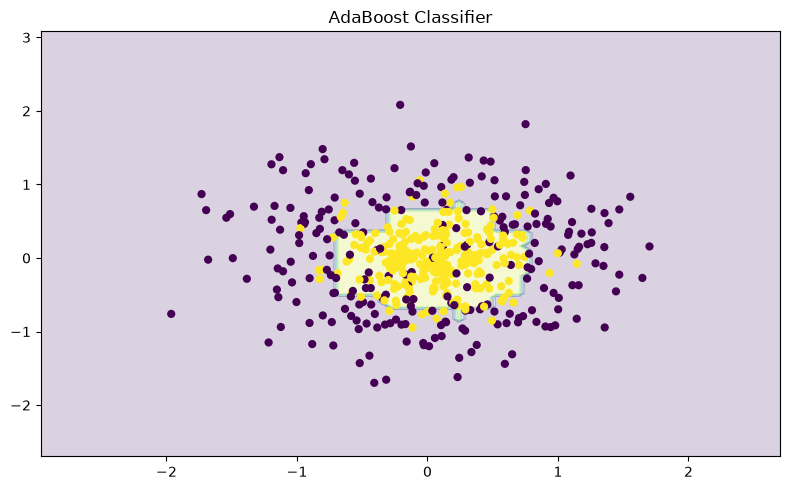

In [47]:
from sklearn.inspection import DecisionBoundaryDisplay 
fig, ax = plt.subplots(figsize=(8, 5))

DecisionBoundaryDisplay.from_estimator(adaboost,X,response_method="predict",cmap="viridis", alpha=0.2,ax=ax)

scatter = ax.scatter(X[:, 0], X[:, 1], c=y,cmap="viridis",  edgecolors="none", s=35 )
plt.title("AdaBoost Classifier")
plt.tight_layout()
plt.show()

### Hyperparameter Tunning using GridSearchCV

In [48]:
from sklearn.model_selection import GridSearchCV 
n_estimators=[10, 50 , 100 , 150 , 500 , 750 , 1000 , 1500]
lr=[0.01 , 0.05 ,0.075, 0.1 ,0.5,0.75, 1]

grid_parms={
    "n_estimators": n_estimators, 
    "learning_rate": lr
}

gd=GridSearchCV(estimator=AdaBoostClassifier() , param_grid=grid_parms , cv=10 , scoring="accuracy" , n_jobs=-1)
gd.fit(X_train , y_train)
print("Best Score :" , gd.best_score_)
print("Best Extimators :" , gd.best_estimator_)
print("Best Parameters :" , gd.best_params_)

Best Score : 0.8275
Best Extimators : AdaBoostClassifier(learning_rate=0.75, n_estimators=750)
Best Parameters : {'learning_rate': 0.75, 'n_estimators': 750}
